<div style="text-align: right"><i>Peter Norvig<br>2016</i></div> 

# The Puzzle of the Misanthropic Neighbors

In this notebook we look at two puzzles, and show how they can be solved by a combination of computational and mathematical thinking.

Consider [this puzzle](http://fivethirtyeight.com/features/can-you-solve-the-puzzle-of-your-misanthropic-neighbors/)  from [The Riddler](http://fivethirtyeight.com/tag/the-riddler/):
    
> *The misanthropes are coming. Suppose there is a row of some number, N, of houses in a new, initially empty development. Misanthropes are moving into the development one at a time and selecting a house at random from those that have nobody in them and nobody living next door. They keep on coming until no acceptable houses remain. At most, one out of two houses will be occupied; at least one out of three houses will be. But what’s the expected fraction of occupied houses as the development gets larger, that is, as N goes to infinity?*



<img src="houses4.jpg" width=400>

To make sure we understand the problem, let's try a simple example, with *N*=4 houses. We will represent the  originally empty row of four houses by four dots:

     Houses:   ....
     
Now the first person chooses one of the four houses (which are all acceptable). We'll indicate an occupied house by a `1`, so the four equiprobable choices are:

     Choice 0: 1...
     Choice 1: .1..
     Choice 2: ..1.
     Choice 3: ...1
     
When a house is occupied, any adjacent houses become unacceptable. We'll indicate that with a `0`:

     Choice 0: 10..
     Choice 1: 010.
     Choice 2: .010
     Choice 3: ..01
     
In all four cases, a second occupant has a place to move in, but then there is no place for a third occupant:

     Choice 0: 10..  →  1010 or 1001
     Choice 1: 010.  →  0101
     Choice 2: .010  →  1010
     Choice 3: ..01  →  0101 or 1001

The occupancy is 2 in all cases, and thus the *expected occupancy* is 2. The occupancy fraction, or *density*, is 2/*N* = 2/4 = 1/2.
     

With *N*=7 houses, there are 7 equiprobable choices for the first occupant:

     Choice 0: 10.....
     Choice 1: 010....
     Choice 2: .010...
     Choice 3: ..010..
     Choice 4: ...010.
     Choice 5: ....010
     Choice 6: .....01
     
Now we'll add something new: the lengths of the **runs** of consecutive acceptable houses to the left and right of the chosen house:

     Choice 0: 10..... runs = (0, 5)
     Choice 1: 010.... runs = (0, 4)
     Choice 2: .010... runs = (1, 3) 
     Choice 3: ..010.. runs = (2, 2) 
     Choice 4: ...010. runs = (3, 1) 
     Choice 5: ....010 runs = (4, 0) 
     Choice 6: .....01 runs = (5, 0) 
     
# Defining occupancy(n)

This gives me a key hint as to how to analyze the problem. I'll define `occupancy(n)` to be the expected number of occupied houses in a row of `n` houses. So:

     Choice 0: 10..... runs = (0, 5); occupancy = occupancy(0) + 1 + occupancy(5)
     Choice 1: 010.... runs = (0, 4); occupancy = occupancy(0) + 1 + occupancy(4)
     Choice 2: .010... runs = (1, 3); occupancy = occupancy(1) + 1 + occupancy(3)
     Choice 3: ..010.. runs = (2, 2); occupancy = occupancy(2) + 1 + occupancy(2)
     Choice 4: ...010. runs = (3, 1); occupancy = occupancy(3) + 1 + occupancy(1)
     Choice 5: ....010 runs = (4, 0); occupancy = occupancy(4) + 1 + occupancy(0)
     Choice 6: .....01 runs = (5, 0); occupancy = occupancy(5) + 1 + occupancy(0)     
     
So we can say that `occupancy(n)` is:

- 0 when `n` is 0 (because no houses means no occupants),
- 1 when `n` is 1 (because one isolated acceptable house has one occupant),
- else the mean, over the `n` choices for the first occupied house,
of the sum of that house plus the occupancy of the runs to the left and right.

We can implement that:

In [1]:
from statistics import mean
from functools import cache

@cache
def occupancy(n: int) -> float:
    """The expected occupancy for a row of n houses (under misanthrope rules)."""
    return (0 if n == 0 else
            1 if n == 1 else
            mean(occupancy(L) + 1 + occupancy(R)
                 for (L, R) in possible_runs(n)))

def possible_runs(n: int) -> list[tuple[int, int]]:
    """A list [(L, R), ...] where the i-th tuple contains the lengths of the runs
    of acceptable houses to the left and right of house i."""
    return [(max(0, i - 1), max(0, n - i - 2))
            for i in range(n)]

Let's check that `occupancy(4)` is 2, as we computed it should be, and for other small values, up to 10:

In [2]:
{n: occupancy(n) for n in range(10)}

{0: 0,
 1: 1,
 2: 1,
 3: 1.6666666666666667,
 4: 2,
 5: 2.466666666666667,
 6: 2.888888888888889,
 7: 3.323809523809524,
 8: 3.7555555555555555,
 9: 4.188007054673721}

That looks good, although I can't prove the value above 4 are correct. Now check that `possible_runs(7)` is what we described above:

In [3]:
assert possible_runs(7) == [(0, 5), (0, 4), (1, 3), (2, 2), (3, 1), (4, 0), (5, 0)]

The problem asks not for the occupancy, but for the "expected fraction of occupied houses," which I will call `density`:

In [4]:
def density(n: int) -> float: 
    """Expected fraction of occupied houses."""
    return occupancy(n) / n

In [5]:
{n: density(n) for n in range(1, 10)}

{1: 1.0,
 2: 0.5,
 3: 0.5555555555555556,
 4: 0.5,
 5: 0.49333333333333335,
 6: 0.48148148148148145,
 7: 0.47482993197278917,
 8: 0.46944444444444444,
 9: 0.46533411718596907}

# Plotting density(n)

The `density(n)` is around 1/2 for all values of *n* > 1. To get a better feel, let's make a plot:

In [6]:
import matplotlib.pyplot as plt

def plot_density(nums: range) -> float:
    """Plot density(n) for each n in `nums`, return desity(max(nums))."""
    plt.xlabel('n houses'); plt.ylabel('density(n)')
    plt.plot(nums, [density(n) for n in nums], 's-')
    return density(max(nums))

0.4422322608865297

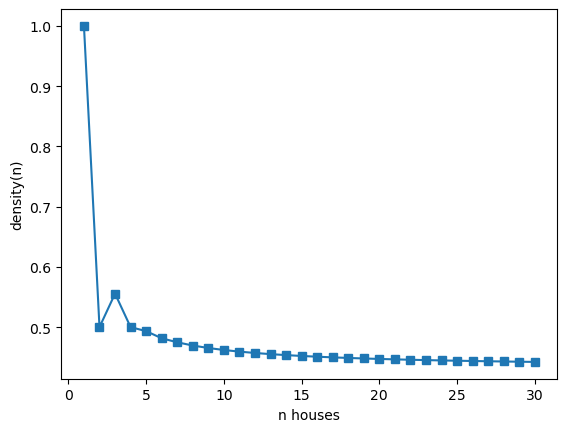

In [7]:
plot_density(range(1, 31))

And let's look at a wider range:

0.4328273535069354

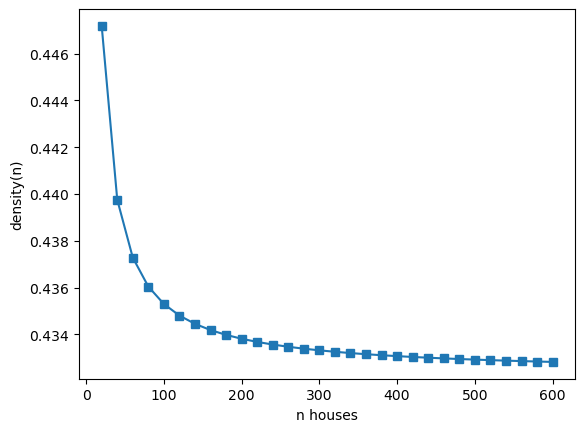

In [8]:
plot_density(range(20, 601, 20))



# lim <sub>n &rarr; &infin;</sub> density(n)

[The puzzle](http://fivethirtyeight.com/features/can-you-solve-the-puzzle-of-your-misanthropic-neighbors/)
is to figure out the limit of `density(n)` as `n` goes to infinity. It looks like something around 0.432, but we can't answer the question just by plotting;  we'll need to switch modes from *computational* thinking to *mathematical* thinking.

At this point I started playing around with `density(n)`, looking at various values, differences of values, ratios of values, and ratios of differences of values, hoping to achieve some mathematical insight. Mostly I got dead ends.
But eventually I hit on something promising. I looked at the difference between density values (using the function `diff`), and particularly the difference as you double `n`:

In [9]:
def diff(n, m) -> float: 
    """The difference in density between n and m houses."""
    return density(n) - density(m)

diff(100, 200)

0.0014849853757253895

And compared that to the difference when you double `n` again:

In [10]:
diff(200, 400)

0.0007424926878626947

Hmm&mdash;I noticed that the first difference is just about twice as much as the second. Let's check:

In [11]:
diff(100, 200) / diff(200, 400)

2.0

Wow&mdash;not only is it *close* to twice as much, it is *exactly* twice as much (to the precision of floating point numbers). Let's try some other random starting values for `n`:

In [12]:
{n: diff(n, 2*n) / diff(2*n, 4*n) for n in (42, 99, 100, 212, 333, 538)}

{42: 2.0000000000000315,
 99: 2.000000000000074,
 100: 2.0,
 212: 2.000000000000317,
 333: 2.0,
 538: 2.0000000000004023}

OK, I'm convinced this is real! 

Now, what mathematical function behaves like this? I figured out that *f*(*n*) = (1 / *n*) does. The ratio of the differences would be:

$$\frac{f(n) - f(2n)}{f(2n) - f(4n)} = \frac{1/n - 1/(2n)}{1/(2n) - 1 / (4n)}\;\;$$

Multiplying top and bottom by *n* you get:


$$\frac{1 - 1/2}{1/2 - 1 /4} = \frac{1/2}{1/4} = 2\;\;$$

If the function (1 / *n*) fits the pattern, then so does any *affine transformation* of (1 / *n*), because we are taking the ratio of differences.  So that means a density function of the form

    density(n) = A + B / n 
    
would fit the patterm.  I can try a `scipy.optimize.curve_fit` to estimate the parameters *A* and *B*:

In [13]:
from scipy.optimize import curve_fit

def estimated_density(n, A, B) -> float: return A + B / n

xdata = list(range(50, 5001, 100))

result = curve_fit(xdata=xdata, ydata=[density(n) for n in xdata], f=estimated_density)

A, B = map(float, result[0])

A, B

(0.43233235838169376, 0.2969970751450662)

We can accept these A and B values:

In [14]:
def estimated_density(n, A=A, B=B) -> float: return A + B / n

And we can test how close this function is to the true `density` function:

In [15]:
float(max(abs(density(n) - estimated_density(n))
      for n in range(200, 2000)))

1.6653345369377348e-16

That says that, for all values of `n` from 200 to 2,000, `density(n)` and `estimated_density(n)` agree at least through the first 15 decimal places!

We now have a plausible answer to the puzzle:

lim<sub style="font-size:large"> <tt>n</tt>&rarr;&infin;</sub> <tt>density(n) &cong; A &cong; 0.43233235838169</tt>

# Why?

This answer is empirically strong (15 decimal places of accuracy) but theoretically weak: we don't have a **proof**, and we don't have an explanation for **why** the density function has this form. We need some more mathematical thinking. 

I didn't have any ideas, so I looked to see if anyone else had written something about the number 0.432332358169 I tried several searches and found two interesting formulas:

- Search: [`[0.4323323]`](https://www.google.com/search?q=0.4323323) Formula: `sinh(1) / exp(1)` [(Page)](http://arxiv.org/pdf/1310.4360.pdf)
- Search: [`[0.432332358]`](https://www.google.com/search?q=0.432332358) Formula: `0.5(1-e^(-2))` [(Page)](https://math.stackexchange.com/questions/1330391/how-to-calculate-e-sin2x)

I can verify that the two formulas are equivalent, and that they are indeed equal to `A` to at least 15 decimal places:

In [16]:
from math import sinh, exp, e

A, sinh(1) / exp(1), 0.5 * (1 - e ** (-2))

(0.43233235838169376, 0.43233235838169365, 0.43233235838169365)

So I now have a suspicion that

> lim <sub>n &rarr; &infin;</sub> density(n) = (1 - e<sup>-2</sup>) / 2

but I still have no proof, nor any intuition as to why this is so.



I reported my results to Anne Paulson and John Lamping, who had originally related the problem to me, and the next day John wrote back with the following:

<blockquote>
I got a derivation of the formula!

<p>Suppose that each house has a different "attractiveness", and that when it is a misanthrope's turn to pick a house, they consider the houses in order, from most attractive to least, and pick the first house not next to any other house. If the attractiveness are chosen independently, this process gives the same probabilities as each misanthrope picking from the available houses randomly.

<p>To be more concrete, let the attractivenesses range from 0 to 1 with uniform probability, with lower numbers being being considered earlier, and hence more attractive. (This makes the math come out easier.)

<p>Given the attractiveness, a, of a house, we can compute the chance that it will end up getting picked. It will get picked if and only if neither house on either side gets considered earlier and gets picked. Lets consider one side, and assume the houses, and their attractivenesses, are labeled a, b, c, d, e, f, g, ... with the house we are considering being a. There are an infinite number of cases where b won't get considered before a and picked. Here are the first few:

<p>   a < b  (a is considered before b)
<p>   a > b > c < d  (Someone considered c first among these 4 and picked it. A later person considered b before a, but rejected it because c had already been chosen.)
<p>   a > b > c > d > e < f (Someone considered e first among these 6, and picked it. A later person considered d, but rejected it because e was chosen, then considered c, which they picked. Still later, someone considered b, which they rejected because c had been chosen.)

<p>We can write down the probabilities of these cases as a function of the attractiveness of a:

<p>   a < b: The chance that b is greater than a: 1 - a.
<p>   a > b > c < d: Let y = a - c, so y is between 0 and a. The probability is the integral over the possible y of the chance that b is between a and c, times the chance that d is greater than c, or integral from 0 to a of y * (1 - a + y) dy.
<p>   a > b > c > d > e < f: Let y = a - e. The probability is the integral of (the chance that b, c, and d are all between a and e, and ordered right, which is y^3 / 3!, times the chance that f is greater than e, which is (1 - a + y))

<p>If you work out the definite integrals, you get

<p>   a < b: 1 - a
<p>   a > b > c < d: a^2 / 2 - a^3 / 3!
<p>   a > b > c > d > e < f: a^4 / 4! - a^5 / 5!

<p>Add them all up, and you have 1 - a + a^2 / 2 - a^3 / 3! + a ^4 / 4! ... the Taylor expansion for e^-a. 

<p>Now, there will be a house at a if both adjacent houses are not picked earlier, so the chance is the square of the chance for one side: e^(-2a). Integrate that from 0 to 1, and you get 1/2 (1 - e^-2).
</blockquote>

You can compare John Lamping's solution to the solutions by [Jim Ferry](http://fivethirtyeight.com/features/the-perplexing-puzzle-of-the-proud-partygoers/) and [Andrew Mascioli](http://andrewmascioli.com/index.php/2016/04/24/the-misanthropic-neighborhood/). 

# Styles of Thinking

It is clear that different write-ups of this problem display different styles of thinking. I'll attempt to name and describe them:

- **Mathematical Publication Style**: This style uses sophisticated mathematics (e.g. generating functions, differentiation, asymptotic analysis, and manipulation of summations). It defines new abstractions without
necessarily trying to motivate them first, it is terse and formal, and it gets us to the conclusion in a way that is
clearly correct, but does not describe all the steps of how the author came up with the ideas. (Ferry and Mascioli)
- **Mathematical Exploration Style**: Like the Mathematical Publication Style, but with more explanatory prose. (Lamping)
- **Computational Thinking**: A more concrete style; tends to use programs with specific values of `n` rather than 
creating a proof for all values of `n`; produces tables or plots to help guide intuition; verifies results
with tests or alternative implementations. (Norvig)

In this specific puzzle, my steps were:
- Analyze the problem and implement code to solve it for small values of `n`.
- Plot results and examine them for insight.
- Play with the results and get a guess at a partial solution <tt>density(n) &cong; A + B / n</tt>.
- Solve numerically for `A` and `B`.
- Do a search with the numeric value of `A` to find a formula with that value.
- Given that formula, let Lamping figure out how it corresponds to the problem.

This is mostly  computational thinking, with a little mathematical thrown in. 


# Validation by Anticipating Objections

Is our implementation of `occupancy(n)` correct? I think it is, but I can anticipate some objections and answer them:

- *In `occupancy(n)`, is it ok to start from all empty houses, rather than considering layouts of partially-occupied houses?* Yes, because the problem states that initially all houses are empty, and each choice of a house breaks the street up into runs of acceptable houses, flanked by unacceptable houses. If we get the computation right for a run of `n` acceptable houses, then we can get the whole answer right. A key point is that the chosen first house breaks the row of houses into 2 runs of *acceptable* houses, not 2 runs of *unoccupied* houses. If it were unoccupied houses, then we would have to also keep track of whether there were occupied houses to the right and/or left of the runs. By considering runs of acceptable houses, eveything is clean and simple.

- *In `occupancy(7)`, if the first house chosen is 2, that breaks the street up into runs of 1 and 3 acceptable houses. There is only one way to occupy the 1 house, but there are several ways to occupy the 3 houses. Shouldn't the average give more weight to the 3 houses, since there are more possibilities there?* No. We are calculating occupancy, and there is a specific number (5/3) which is the expected occupancy of 3 houses; it doesn't matter if there is one combination or a million combinations that contribute to that expected value, all that matters is what the expected value is.




# Validation by Unit Tests

Another way to gain more confidence in the code is to run a test suite:

In [17]:
def test():
    assert occupancy(0) == 0
    assert occupancy(1) == occupancy(2) == 1
    assert occupancy(3) == 5/3
    assert density(3) == occupancy(3) / 3
    assert density(100) == occupancy(100) / 100
    assert possible_runs(3) == [(0, 1), (0, 0), (1, 0)]
    assert possible_runs(7) == [(0, 5), (0, 4), (1, 3), (2, 2), (3, 1), (4, 0), (5, 0)]   
    return 'ok'

test()

'ok'

# Validation by Simulation


A simulation can add credence to our implementation of `density(n)`, for two reasons:
- The code for the simulation can  have a more direct correspondance to the problem statement.
- When two very different implementations get the same result, that is evidence supporting both of them.


The simulation will start with an empty set of occupied houses. We then go through the houses in random order (order of attractiveness as John Lamping puts it), occupying just the ones that have no neighbor.

In [18]:
import random

def simulate_houses(n: int) -> set[int]:
    "Simulate moving in to houses, and return a set of occupied houses."
    occupied = set()
    for house in random_order(range(n)):
        if (house - 1) not in occupied and (house + 1) not in occupied:
            occupied.add(house)
    return occupied

def random_order(items): return random.sample(items, len(items))

In [19]:
def simulated_density(n, repeat=10_000):
    "Estimate density by simulation, repeated `repeat` times."
    return mean(len(simulate_houses(n)) / n 
                for _ in range(repeat))

Let's measure the deltas for the simulation results (and the `estimated_sensity` results) compared to the actual `density` results:

In [20]:
print('   n   density   Δsimulated   Δestimated')
for n in range(50, 301, 50):
    s, d, e = simulated_density(n), density(n), estimated_density(n)
    print(f'{n:4d}   {d:.4f}    {d-s:+9.1e}    {d-e:+9.1e}')

   n   density   Δsimulated   Δestimated
  50   0.4383     -1.7e-04     +1.7e-16
 100   0.4353     -5.5e-05     +5.6e-17
 150   0.4343     +3.2e-05     +5.6e-17
 200   0.4338     -2.7e-06     +0.0e+00
 250   0.4335     -9.8e-05     +0.0e+00
 300   0.4333     -2.7e-05     -5.6e-17


We get good agreement, to at least to 4 decimal places for the simulated runs and 16 decimal places for the estimated density, suggesting that either our three implementations are all correct, or we've made similar mistakes in all three. 

The `simulate` function can also give us insights when we look at the results it produces:

In [21]:
from collections import Counter

Counter(tuple(simulate_houses(7)) for _ in range(10_000))

Counter({(0, 2, 4, 6): 3264,
         (1, 3, 5): 1431,
         (0, 2, 5): 1248,
         (1, 4, 6): 1192,
         (1, 3, 6): 1036,
         (0, 3, 5): 981,
         (0, 3, 6): 848})

That says that about 1/3 of the time, things work out so that the 4 even-numbered houses are occupied. But if anybody ever chooses an odd-numbered house, then we are destined to have 3 houses occupied (in one of 6 different ways, of which (1, 3 5) is the most common, probably because it is the only one that has three chances of getting started with an odd-numbered house).

# Conclusion

I'm happy with my result:

> <tt>lim <sub>n &rarr; &infin;</sub> density(n) = (1 - e<sup>-2</sup>) / 2 &cong; 0.43233235838169365 </tt>

I got the fun of working on the puzzle, the satisfaction of seeing John Lamping work out a proof, and the awe of seeing the mathematically sophisticated solutions of Jim Ferry and Andrew Mascioli, solutions that I know I could never come up with, but that I could get near to by coming at the problem with a different style of thinking.

# Postscript: Another Puzzle Solved by Simulation

The [538 Riddler column from Jan 28, 2021](https://fivethirtyeight.com/features/can-you-cut-the-square-into-more-squares/) poses this question:

> *Robin of Foxley has entered the FiveThirtyEight archery tournament. Her aim is excellent (relatively speaking), as she is guaranteed to hit the circular target, which has no subdivisions — it’s just one big circle. However, her arrows are equally likely to hit each location within the target.*
>
>*Her true love, Marian, has issued a challenge. Robin must fire as many arrows as she can, such that each arrow is closer to the center of the target than the previous arrow. For example, if Robin fires three arrows, each closer to the center than the previous, but the fourth arrow is farther than the third, then she is done with the challenge and her score is four.*
>
>*On average, what score can Robin expect to achieve in this archery challenge?*

The tournament can potentially have an infinite number of arrows, so the mathematical solution will be the sum of an infinite series. I don't have a good idea how to figure that out, but I know I can do a simulation. I'll make the target be the unit circle, and represent the point an arrow hits by a complex number, which is a point in the (real, imag) plane. Then the distance to the center of the target is just the absolute value of the point.

In [22]:
Point = complex
distance = abs

def random_arrow() -> Point:
    """A random point within the unit circle.
    Found by sampling uniformly from a bounding square until we get a point inside the unit circle."""
    while distance(arrow := Point(random.uniform(-1, 1), random.uniform(-1, 1))) > 1:
        pass
    return arrow

Let's make sure the random arrows look right:

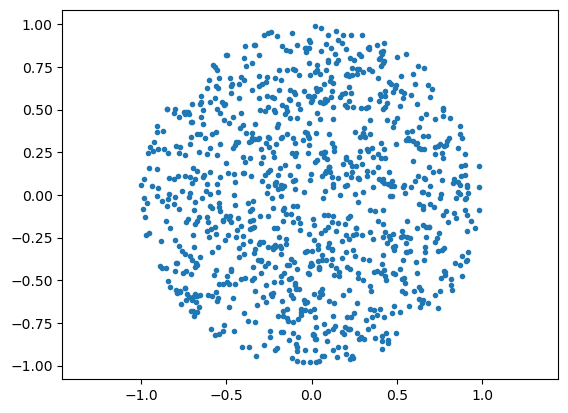

In [23]:
arrows = [random_arrow() for _ in range(1000)]
plt.axis('equal')
plt.plot([a.real for a in arrows], [a.imag for a in arrows], '.');

A simulated tournament consists of placing random arrows until one of them is further away from the center than a previous one:

In [24]:
def simulate_archery(previous_arrows=()) -> int:
    """Simulate the archery tournament and return the number of arrows fired."""
    arrow = random_arrow()
    if any(abs(arrow) > distance(a) for a in previous_arrows):
        return len(previous_arrows) + 1
    else:
        return simulate_archery([*previous_arrows, arrow])

Now we can run this for say, a million times and take the mean:

In [25]:
mean(simulate_archery() for _ in range(1_000_000))

2.718797

Wow! 2.718! I know that number, it's a [**friend from work**](https://www.youtube.com/watch?v=wjwD1ZGz1UM)!

I know that *e* = 1/0! + 1/1! + 1/2! + 1/3! + ...

Now I recognize how this applies to the problem! Before seeing this number, if you had asked me, I would have said that the average should be somewhere around 3, and if you told me it was a famous irrational number, I would have guessed π, not *e*. But upon seeing the factorial signs, I see that it doesn't matter that the arrows are on a circle, what matters is the relative distances of the arrows, and for *n* arrows there are *n*! possible orderings. I wrote up how I went from that insight to a proof that *e* is the answer, but unfortunately I can't find the writeup now, so I'll repeat [the solution given by 538](https://fivethirtyeight.com/features/can-you-hunt-for-the-mysterious-numbers/):

>Solver Balthazar Potet approached this by thinking about the values for the first N arrows Robin fired and the probability they’d result in a score of N. With any N values, there were N! ways to order them. For Robin to have a score of N, the smallest value couldn’t have been in the Nth position, since it had to be greater than the previous value. And when each of the other N−1 values occurred in the Nth position, there was exactly one way to order the remaining values so that they formed a decreasing sequence. So of the N! orderings, N−1 resulted in a score of N, meaning the probability was (N−1)/N!

>From there, you had to use these probabilities to compute an average score, which you could find by multiplying each score by its probability and then adding up all those products. The probability Robin scored 2 was (2−1)/2!, or 1/2, which meant a score of 2 contributed 2·1/2, or 1, to her average score. The probability Robin scored 3 was (3−1)/3!, or 1/3, which meant a score of 3 contributed 3·1/3, or 1 (again!), to her average score. In general, the probability Robin scored N was (N−1)/N!, which meant a score of N contributed N·(N−1)/N!, or 1/(N−2)!, to her average score. Since N was at least 2 — meaning Robin fired at least two arrows — her average score was 1/0! + 1/1! + 1/2! + 1/3! + …, a sum that converges to *e*, which is approximately 2.71828. Huzzah, another riddle whose answer was a famous mathematical constant!